### This code calibrates and the process-based models in the DWD dataset (Sections 3.1 and 3.2 and Supplementary Figures 2 and 3)

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import scipy.optimize
import scipy.stats
import scipy
from scipy.integrate import quad
import scipy.stats as stats
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
import copy
import calendar
from optimise_GDD_fctns import * #Phenology_set, run_GDD_and_get_RMSE, run_GDD_and_get_RMSE_derivs, plot_profiles_at_minimum, get_station_locations, put_ERA5_in_array

#import seaborn as sns

import plotting
import dataset_fctns
import modelling_fctns
import seaborn as sns
#from dwd_phenpy import Phenology_set

#import openeo
#import ee
## Trigger the authentication flow.
#ee.Authenticate()#(auth_mode='localhost')
# Initialize the library.
#ee.Initialize(project='ee-martinparker637')

c:\Users\wlwc1989\Documents\Phenology_Test_Notebooks\modelling_crop_phenology_in_data_scarce_regions_using_transfer_learning_code\process_based\parameter_calibration_model_evaluation\optimise_GDD_fctns.py:35: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  station_data = pd.read_csv("https://opendata.dwd.de/climate_environment/CDC/help/PH_Beschreibung_Phaenologie_Stationen_Jahresmelder.txt",sep = ";\s+|;\t+|;\s+\t+|;\t+\s+|;|\s+;|\t+;|\s+\t+;|\t+\s+;", encoding='cp1252', on_bad_lines='skip')


### First write some calibration and evalution functions

In [2]:
def run_GDD(x, ds, driver_variable, latlon_proj = True, response_type = 'Trapezoid', 
                             phase_list = ['beginning of flowering'], exclude_unfinished = False,
                             growing_period_length = 300, thresholds = [100], 
                             title_extra='', method='scatter', savename = False, plot=False, col='blue',
                             step = 0.25):
    if response_type == 'Trapezoid':
        def response(meantemp):
            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
            return x[0]*modelling_fctns.Trapezoid_Temp_response(meantemp, x[1], x[2], 0.2, 3)#x[3], x[4])
    elif response_type == 'Wang':
        def response(meantemp):
            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
            return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
    elif response_type == 'Convolved':
        #table = vec_expint(x[1], x[2], x[3], np.arange(0, 50, 0.5), 8, 3)#, x[4], x[5])#x[2]
        table2 = Convolved_Wang_Engel(np.arange(-10, 50, step), x[1], x[2], x[3], 3)
        table = scipy.ndimage.gaussian_filter(table2, 8/step, mode='constant', cval = 0, axes=0)
        def response(meantemp):
            return x[0]*table[(np.round(meantemp/step, decimals = 1)).astype(int) + int(10/step)]*(meantemp > -10)
    elif response_type == 'Convolved_vary_spread':
        #table = vec_expint(x[1], x[2], x[3], np.arange(0, 50, 0.5), x[4], x[5])#, x[4], x[5])#x[2]
        table2 = Convolved_Wang_Engel(np.arange(-10, 50, step), x[1], x[2], x[3], x[5])
        table = scipy.ndimage.gaussian_filter(table2, x[4]/step, mode='constant', cval = 0, axes=0)
        def response(meantemp):
            return x[0]*table[(np.round(meantemp/step, decimals = 1)).astype(int) + int(10/step)]*(meantemp > -10)
        #def response(meantemp):
        #    return x[0]*table[(np.round(meantemp/5, decimals = 1)*10).astype(int)]*(meantemp > 0)
    elif response_type == 'multi_phase':
        def response(meantemp):
            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
            return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
        responses = [lambda meantemp: x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3]),
                     lambda meantemp: x[4]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[5], x[6], x[7])]
    driver_columns = [f'{driver_variable} at day {day}' for day in range(growing_period_length)]
    ds_for_model = ds[driver_columns + ['year', 'Stations_id']].copy()
    #ds_for_model.loc[:, driver_columns] = ds_for_model.loc[:, driver_columns]#.round(decimals = 10).astype(np.float64)
    if response_type == 'multi_phase':
        t_dev = np.zeros(len(ds_for_model))
        for i, colm in enumerate(driver_columns):
            resp = modelling_fctns.phase_dependent_response2(ds_for_model.loc[:, colm], t_dev, responses, thresholds)
            #resp2 = response(ds_for_model.loc[:, colm])
            #if np.any(resp != resp2):
            #    print(resp, resp2)
            #print(resp)
            t_dev += resp
            ds_for_model.loc[:, colm] = t_dev
    else:
        ds_for_model.loc[:, driver_columns] = response(ds_for_model[driver_columns]).cumsum(axis=1)
    model_dev_time_series = ds_for_model.values.T
    column_names = np.concatenate([np.array([f'modelled time to {phase}' for phase in phase_list]), ['year'], ['Stations_id']])
    thresholds_for_phase = thresholds[-1:]
    #print(thresholds_for_phase, model_dev_time_series.shape[1])
    phase_dates_array = np.zeros((len(thresholds_for_phase), model_dev_time_series.shape[1]))#
    for obs_index in range(model_dev_time_series.shape[1]):
        #print(model_dev_time_series[:-2, obs_index])
        phase_dates_array[:, obs_index] = np.digitize(thresholds_for_phase, model_dev_time_series[:-2, obs_index].astype(np.float64))    
    #print(phase_dates_array)
    phase_dates_array = np.concatenate([phase_dates_array, [model_dev_time_series[-2]], [model_dev_time_series[-1]]], axis=0)
    phase_dates_array = pd.DataFrame(phase_dates_array.T, columns = column_names)
    comparison_array = ds.merge(phase_dates_array, how='left', on=['year', 'Stations_id']).dropna(how='all')
    #print(len(ds), len(comparison_array), len(phase_dates_array))
    if plot:
        plot_from_comparison_array(comparison_array, title_extra=title_extra, method=method, savename=savename, 
                                  phase_list=phase_list, exclude_unfinished=exclude_unfinished, growing_period_length=growing_period_length,
                                  col=col)
    return comparison_array

In [3]:
def run_GDD_and_get_RMSE(x, ds, driver_variable, latlon_proj = True, 
                         response_type = 'Trapezoid', phase_list = ['beginning of flowering'], 
                         new_unfinished_penalisation=False,
                         growing_period_length = 300, thresholds = [100]):
    comparison_array = run_GDD(x, ds, driver_variable, latlon_proj=latlon_proj,
                               response_type=response_type, phase_list=phase_list,
                               growing_period_length=growing_period_length, thresholds=thresholds)
    unfinished_penalty=0
    if new_unfinished_penalisation:
        unfinished_penalty = max((comparison_array[f'modelled time to {phase_list[0]}'] >growing_period_length - 3).sum() - 0.03*comparison_array.shape[0], 0)
        comparison_array = comparison_array.where(comparison_array[f'modelled time to {phase_list[0]}'] < growing_period_length).dropna()
    def RMSE(residuals):
        if len(residuals) == 0:
            return 0
        else:
            return np.sqrt(np.mean(residuals**2))
    phase = phase_list[0]
    residuals = (comparison_array[f'observed time to {phase}'] - comparison_array[f'modelled time to {phase}']).values # np.concatenate([(comparison_array[f'observed time to {phase}'].dt.days - comparison_array[f'modelled time to {phase}']).values for phase in phase_list])
    return RMSE(residuals) + unfinished_penalty#, comparison_array


In [4]:
def train_test_by_year(ds, test_years):
    obs_for_testing = ds['year'].isin(test_years)
    train_ds = ds[~obs_for_testing]
    test_ds = ds[obs_for_testing]
    return train_ds, test_ds

In [5]:
def plot_from_comparison_array(comparison_array, title_extra='', method='scatter', savename = False, phase_list = ['beginning of flowering'], exclude_unfinished = False, growing_period_length = 300, col = 'blue'):
    if method == 'both':
        fig, axs = plt.subplots(len(phase_list), 2, figsize = (10, len(phase_list)*5))
    else:
        fig, axs = plt.subplots(1, len(phase_list), figsize = (len(phase_list)*5, 5))
    for phase_index, phase in enumerate(phase_list):
        number_unfinished = (comparison_array[f'modelled time to {phase}'] >= growing_period_length).sum()
        number_total = len(comparison_array)
        print(f'{number_unfinished} stations out of {number_total} did not reach the end of phase \'{phase}\'')
        if exclude_unfinished:
            comparison_array = comparison_array[comparison_array[f'modelled time to {phase}'] < growing_period_length].dropna()
        #comparison_array[f'observed time to {phase}'] = comparison_array[f'observed time to {phase}'].dt.days
        if len(phase_list) == 1:
            ax = axs
        else:
            ax = axs[phase_index]
        if method == 'regression':
            #x_estimator=np.mean,
            #minval = min(comparison_array[f'observed time to {phase}'].min(), comparison_array[f'modelled time to {phase}'].min()) - 1
            #maxval = max(comparison_array[f'observed time to {phase}'].max(), comparison_array[f'modelled time to {phase}'].max()) + 1
            minval = min(comparison_array[f'observed time to {phase}'].quantile(0.05), comparison_array[f'modelled time to {phase}'].quantile(0.05)) - 1
            maxval = max(comparison_array[f'observed time to {phase}'].quantile(0.95), comparison_array[f'modelled time to {phase}'].quantile(0.95)) + 1
            sns.regplot(x=f'modelled time to {phase}', y=f'observed time to {phase}', data=comparison_array, ax=axs,
                        scatter_kws={'alpha':0.5, 's':4},  x_bins=np.arange(minval - 5, maxval + 5, 2.5), color=col)
            axs.plot([minval, maxval], [minval, maxval], linestyle='--', color='k', lw=1, scalex=False, scaley=False)
            axs.set_xlim(minval, maxval)
            axs.set_ylim(minval, maxval)
            axs.set_title(f'Modelled and observed time to {phase}\n{title_extra}')
        elif method == 'errors':
            comparison_array['error'] = comparison_array[f'observed time to {phase}'] - comparison_array[f'modelled time to {phase}']
            sns.regplot(x=f'modelled time to {phase}', y='error', data=comparison_array, ax=axs,
                        scatter_kws={'alpha':0.5, 's':4},  x_bins=np.arange(30, 200, 5))
            axs.set_title(f'Comparison of fitted values and residuals {phase}\n{title_extra}')
        elif method == 'histogram':
            sns.histplot(x=f'modelled time to {phase}', data = comparison_array, ax=ax, label = 'modelled days to anthesis',
                        stat = 'density')
            sns.histplot(x=f'observed time to {phase}', data = comparison_array, ax=ax, label= 'observed days to anthesis',
                        stat = 'density')
            sns.set(font_scale=1.5)
            axs.set_title(f'Comparison of GDD modelled and observed time to\n{phase} {title_extra}')
            ax.set_xlabel('Days after planting')
            #ax.plot([minval, maxval], [minval, maxval], linestyle = '--', color='k')
            fig.legend(bbox_to_anchor = (1.2, 0.9))
            rsquared = r2_score(comparison_array[f'observed time to {phase}'], comparison_array[f'modelled time to {phase}'])
            print(f'R^2 value for model: {rsquared}')
            bias = comparison_array[f'observed time to {phase}'].mean() - comparison_array[f'modelled time to {phase}'].mean()
            variance_modelled = comparison_array[f'modelled time to {phase}'].var()
            print(f'Bias: {bias**2}\nVariance of modelled values: {variance_modelled}')
        elif method == 'both':
            ax = axs[0]
            minval = min(comparison_array[f'observed time to {phase}'].quantile(0.05), comparison_array[f'modelled time to {phase}'].quantile(0.05)) - 1
            maxval = max(comparison_array[f'observed time to {phase}'].quantile(0.95), comparison_array[f'modelled time to {phase}'].quantile(0.95)) + 1
            sns.regplot(x=f'modelled time to {phase}', y=f'observed time to {phase}', data=comparison_array, ax=ax,
                        scatter_kws={'alpha':0.5, 's':4},  x_bins=np.arange(minval - 5, maxval + 5, 5))
            ax.plot([minval, maxval], [minval, maxval], linestyle='--', color='k', lw=1, scalex=False, scaley=False)
            ax.set_xlim(minval, maxval)
            ax.set_ylim(minval, maxval)
            
            ax = axs[1]
            sns.histplot(x=f'modelled time to {phase}', data = comparison_array, ax=ax, label = 'modelled days to anthesis',
                        stat = 'density')
            sns.histplot(x=f'observed time to {phase}', data = comparison_array, ax=ax, label= 'observed days to anthesis',
                        stat = 'density')
            sns.set(font_scale=1.5)
            fig.suptitle(f'Comparison of GDD modelled and observed time to\n{phase} {title_extra}')
            ax.set_xlabel('Days after planting', fontsize = 18)
            ax.set_ylabel('Density', fontsize = 18)
            #ax.plot([minval, maxval], [minval, maxval], linestyle = '--', color='k')
            fig.legend(bbox_to_anchor = (1.2, 0.8))
            fig.tight_layout()
    rsquared = r2_score(comparison_array[f'observed time to {phase}'], comparison_array[f'modelled time to {phase}'])
    print(f'R^2 value for model: {rsquared}')
    bias = comparison_array[f'observed time to {phase}'].mean() - comparison_array[f'modelled time to {phase}'].mean()
    variance_modelled = comparison_array[f'modelled time to {phase}'].var()
    print(f'Bias: {bias**2} (sign {np.sign(bias)})\nVariance of modelled values: {variance_modelled}')
    if savename != False:
        fig.savefig(f'plots/{savename}', bbox_inches='tight')

In [6]:
def local_opt(x1s, train, test, error_fctn = run_GDD_and_get_RMSE, lower_bounds = [0.05, 4, 20, 20, 35], upper_bounds = [1, 12, 35, 35, 60], #ds
              great_threshold = 13, response_type = 'Trapezoid', phase_list = ['yellow ripeness'],
              method = 'trust-constr', modified_cost = False, thresholds = [100], growing_period_length = 185,
              maxiter = 50, split = True, CCNN_split = False, test_size = 0.5, random_state=1, itr = 0.5, bias_term = False):
    #if split:
    #    train, test = train_test_split(ds, test_size=test_size, random_state = random_state)
    #    #train_indices = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\model_output\\temp_CCNN_training.csv')
    #elif CCNN_split:
    #    test_indices = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\model_output\\compare_CCNN_results.csv')
    #    train_indices = train_indices.rename(columns = {'year': 'Referenzjahr'})
    #    test_indices = test_indices.rename(columns = {'year': 'Referenzjahr'})
    #    test = pd.merge(ds, test_indices[['Stations_id', 'Referenzjahr']], on = ['Stations_id', 'Referenzjahr'])
    #    complement_indices = ds.index.difference(test.index)
    #
    #    # Filter df2 to keep only the rows with the complement indices
    #    train = ds.loc[complement_indices]
    #    #train = pd.merge(ds, train_indices[['Stations_id', 'Referenzjahr']], on = ['Stations_id', 'Referenzjahr'])
    #    test = pd.merge(ds, test_indices[['Stations_id', 'Referenzjahr']], on = ['Stations_id', 'Referenzjahr'])
    #else:
    #    train = ds
    #    test = ds
    only_phase = phase_list[0]
    if response_type == 'Trapezoid':
        ineq_cons = {'type': 'ineq',
                    'fun' : lambda x: np.array([x[2] - x[1],
                                                x[3] - x[2],
                                                x[4] - x[3]]),
                    'jac' : lambda x: np.array([[0, -1, 1, 0, 0],
                                                [0, 0, -1, 1, 0],
                                                [0, 0, 0, -1, 1]])}
        constraints = scipy.optimize.LinearConstraint([[0, -1, 1, 0, 0], [0, 0, -1, 1, 0], [0, 0, 0, -1, -1]], [0, 0, 0], [np.inf, np.inf, np.inf])
    elif response_type == 'Wang' or response_type == 'Convolved':
        ineq_cons = {'type': 'ineq',
                    'fun' : lambda x: np.array([x[2] - x[1],
                                                x[3] - x[2]]),
                    'jac' : lambda x: np.array([[0, -1, 1, 0],
                                                [0, 0, -1, 1]])}
        ieq_cons = [lambda x: x[2] - x[1],
                    lambda x: x[3] - x[2]]
        if bias_term:
            constraints = scipy.optimize.LinearConstraint(np.array([[0, -1, 1, 0, 0], [0, 0, -1, 1, 0]]),lb= [0, 0], ub=[1000, 1000])
        else:  
            constraints = scipy.optimize.LinearConstraint(np.array([[0, -1, 1, 0], [0, 0, -1, 1]]),lb= [0, 0], ub=[1000, 1000])
    elif response_type == 'Convolved_vary_spread':
        ineq_cons = {'type': 'ineq',
                    'fun' : lambda x: np.array([x[2] - x[1],
                                                x[3] - x[2]]),
                    'jac' : lambda x: np.array([[0, -1, 1, 0, 0, 0],
                                                [0, 0, -1, 1, 0, 0]])}
        ieq_cons = [lambda x: x[2] - x[1],
                    lambda x: x[3] - x[2]]
        constraints = scipy.optimize.LinearConstraint(np.array([[0, -1, 1, 0, 0, 0], [0, 0, -1, 1, 0, 0]]),lb= [0, 0], ub=[1000, 1000])
    elif response_type == 'Convolved':
        ineq_cons = {'type': 'ineq',
                    'fun' : lambda x: np.array([x[2] - x[1],
                                                x[3] - x[2]]),
                    'jac' : lambda x: np.array([[0, -1, 1, 0],
                                                [0, 0, -1, 1]])}
        ieq_cons = [lambda x: x[2] - x[1],
                    lambda x: x[3] - x[2]]
        constraints = scipy.optimize.LinearConstraint(np.array([[0, -1, 1, 0, 0, 0], [0, 0, -1, 1, 0, 0]]),lb= [0, 0], ub=[1000, 1000])
    elif response_type == 'Spline':
        ineq_cons = {'type': 'ineq',
                    'fun' : lambda x: np.array([x[2],
                                                x[3]]),
                    'jac' : lambda x: np.array([[0 for count in range(20)],
                                                [0 for count in range(20)]])}
        ieq_cons = [lambda x: x[2] - x[1],
                    lambda x: x[3] - x[2]]
        constraints = scipy.optimize.LinearConstraint(np.array([[0 for count in range(20)], [0 for count in range(20)]]),lb= [-1, -1], ub=[1000, 1000])
    elif response_type == 'multi_phase':
        ineq_cons = {'type': 'ineq',
                    'fun' : lambda x: np.array([x[2] - x[1],
                                                x[3] - x[2],
                                                x[6] - x[5],
                                                x[7] - x[6]]
                                                ),
                    'jac' : lambda x: np.array([[0, -1, 1, 0, 0, -1, 1, 0],
                                                [0, 0, -1, 1, 0, 0, -1, 1]])}
        ieq_cons = [lambda x: x[2] - x[1],
                    lambda x: x[3] - x[2]]
        if bias_term:
            constraints = scipy.optimize.LinearConstraint(np.array([[0, -1, 1, 0, 0], [0, 0, -1, 1, 0]]),lb= [0, 0], ub=[1000, 1000])
        else:  
            constraints = scipy.optimize.LinearConstraint(np.array([[0, -1, 1, 0], [0, 0, -1, 1]]),lb= [0, 0], ub=[1000, 1000])
    bounds = scipy.optimize.Bounds(lb=lower_bounds, ub = upper_bounds)
    x0 = np.array([1, 4, 25, 35, 45])
    final_mins = []
    for x0 in x1s:
        if method == 'trust-constr':
            res = scipy.optimize.minimize(lambda x: error_fctn(x, train, 't2m', 
                                                                         response_type = response_type, 
                                                                         phase_list = phase_list, 
                                                                         new_unfinished_penalisation=modified_cost, 
                                                                         growing_period_length = growing_period_length,
                                                                         thresholds = thresholds), 
                                    x0, method = 'trust-constr',#'COBYQA',
                                    #jac='3-point',#
                                    jac = lambda x: run_GDD_and_get_RMSE_derivs(x, train, 't2m', #jac='3-point',#[x0/1000 for x0 in 
                                                                                response_type = response_type, 
                                                                                phase_list = phase_list, 
                                                                                growing_period_length=growing_period_length,
                                                                                thresholds = thresholds),#
                                    constraints=[constraints],
                                    options={'verbose': 3, 'initial_tr_radius': itr, 'xtol':1e-7, 'maxiter':maxiter},# ,'gtol':1e-7, 'finite_diff_rel_step': 0.05
                                    bounds=bounds, tol=1e-9)
        elif method == 'SLSQP':
            res = scipy.optimize.minimize(lambda x: error_fctn(x, train, 't2m', 
                                                                         response_type = response_type, 
                                                                         phase_list = phase_list,
                                                                         new_unfinished_penalisation=modified_cost,
                                                                         growing_period_length=growing_period_length,
                                                                         thresholds = thresholds), 
                                    x0, method = 'SLSQP',
                                    #jac = '3-point',
                                    jac = lambda x: run_GDD_and_get_RMSE_derivs(x, train, 't2m', 
                                                                                response_type = response_type, 
                                                                                phase_list = phase_list, 
                                                                                growing_period_length=growing_period_length,
                                                                                thresholds = thresholds),#jac='3-point',#
                                    constraints=[ineq_cons],
                                    options={'disp': 3, 'maxiter':maxiter, 'ftol': 1e-16},
                                    bounds=bounds)#, tol=1e-15)
        elif method == 'Nelder-Mead':
            res = scipy.optimize.minimize(lambda x: error_fctn(x, train, 't2m', 
                                                                         response_type = response_type, 
                                                                         phase_list = phase_list,
                                                                         new_unfinished_penalisation=modified_cost,
                                                                         growing_period_length=growing_period_length,
                                                                         thresholds = thresholds), 
                                    x0, method = 'Nelder-Mead',
                                    #jac = '3-point',
                                    #jac = lambda x: run_GDD_and_get_RMSE_derivs(x, train, 't2m', 
                                    #                                            response_type = response_type, 
                                    #                                            phase_list = phase_list, 
                                    #                                            growing_period_length=growing_period_length,
                                    #                                            thresholds = thresholds),#jac='3-point',#
                                    options={'disp': True, 'fatol': 1e-10},#, 'maxiter':50
                                    bounds=bounds)#, tol=1e-15)
        elif method == 'Powell':
            res = scipy.optimize.minimize(lambda x: error_fctn(x, train, 't2m', 
                                                                         response_type = response_type, 
                                                                         phase_list = phase_list,
                                                                         new_unfinished_penalisation=modified_cost,
                                                                         growing_period_length=growing_period_length,
                                                                         thresholds = thresholds), 
                                    x0, method = 'Powell',
                                    #jac = '3-point',
                                    #jac = lambda x: run_GDD_and_get_RMSE_derivs(x, train, 't2m', 
                                    #                                            response_type = response_type, 
                                    #                                            phase_list = phase_list, 
                                    #                                            growing_period_length=growing_period_length,
                                    #                                            thresholds = thresholds),#jac='3-point',#
                                    options={'disp': True},#, 'maxiter':50
                                    bounds=bounds)
        print(x0, res.x, x0 - res.x)
        RMSE = error_fctn(res.x, test, 't2m', response_type = response_type, phase_list = phase_list, growing_period_length = growing_period_length, thresholds = thresholds)
        #print('R^2: ', r2_score(c_array[f'observed time to {only_phase}'], c_array[f'modelled time to {only_phase}']))
        print('RMSE at opt on test set: ', RMSE)
        print('R^2:', 1 - (RMSE**2/(test[f'observed time to {only_phase}'].var()*((len(test) - 1)/len(test)))))
        final_mins.append(res.x)
    return final_mins, res, train, test

In [7]:
def run_GDD_and_get_RMSE_derivs(x, ds, driver_variable = 't2m', latlon_proj = True, response_type = 'Trapezoid', 
                                phase_list = ['beginning of flowering'],growing_period_length = 300,
                                thresholds = [100]):
    only_phase = phase_list[0]
    if response_type == 'Trapezoid':
        def response(meantemp):
            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
            return x[0]*modelling_fctns.Trapezoid_Temp_response(meantemp, x[1], x[2], x[3], x[4])
    elif response_type == 'Wang':
        def response(meantemp):
            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
            return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])

    ## Initiate development time storage object - a list with a value for all the stations, that will change over time and be stored in a list.
    t_dev = np.zeros(len(ds)) #Continuous development time. When this passes through some thresholds then have change in phase.
    accumulated_deriv_time_series = [[t_dev.copy()] for count in range(len(x))]
    dev_time_series = [t_dev.copy()]
    list_of_responses = [] 
    #Run model
    for day in range(growing_period_length):
        # Pull values for temperature out of data frame
        driver_values = ds[f'{driver_variable} at day {day}'].values
        resp = response(driver_values)
        # Calculate the response for each of these temperatures and add it to the total accumulated temperature
        if response_type == 'Trapezoid':
            response_deriv = x[0]*Trapezoid_Temp_derivs(driver_values, x[1], x[2], x[3], x[4])
            response_deriv[0, :] = response_deriv[0, :]/x[0]
        elif response_type == 'Wang':
            response_deriv_no_scale = Wang_Temp_Derivs(driver_values, x[1], x[2], x[3])
            response_deriv = [resp/x[0]] + [x[0]*deriv for deriv in response_deriv_no_scale]
        for x_index in range(len(x)):
            accumulated_deriv_time_series[x_index].append(accumulated_deriv_time_series[x_index][-1] + response_deriv[x_index])
        t_dev += resp#, t_dev)
        list_of_responses.append(resp)
        #print(len(accumulated_deriv_time_series[0][-1]))
        #print(accumulated_deriv_time_series[0][-1], t_dev/x[0])
        #Store the accumulated temperature in an array
        dev_time_series.append(t_dev.copy())

    # Add the year and station codes for indexing later and to check that extracting values didn't mix up indexes
    dev_time_series.append(ds['year'].values)
    dev_time_series.append(ds['Stations_id'].values)
    #print([p.shape for p in dev_time_series])
    model_dev_time_series = np.array(dev_time_series)
    #driver_array['Development Time'] = (('days from emergence', 'Emergence observation'), model_dev_time_series)
    column_names = np.concatenate([np.array([f'modelled time to {phase}' for phase in phase_list]), ['year'], ['Stations_id']])
    phase_dates_array = np.zeros((len(thresholds), model_dev_time_series.shape[1]))
    resps_list = np.zeros(model_dev_time_series.shape[1])
    for obs_index in range(model_dev_time_series.shape[1]):
        phase_dates_array[:, obs_index] = np.digitize(thresholds, model_dev_time_series[:-2, obs_index].astype(np.float64)) - 1
        resps_list[obs_index] = list_of_responses[int(phase_dates_array[-1, obs_index]) - 1][obs_index].mean()
    resps_list += 0.1*x[0]*(resps_list == 0)
    #print(phase_dates_array)
    phase_dates_array = np.concatenate([phase_dates_array, [model_dev_time_series[-2]], [model_dev_time_series[-1]]], axis=0)
    phase_dates_array = pd.DataFrame(phase_dates_array.T, columns = column_names).astype('int64')
    for x_index in range(len(x)):
        accumulated_derivs = accumulated_deriv_time_series[x_index]
        accumulated_derivs.append(ds['year'].values)
        accumulated_derivs.append(ds['Stations_id'].values)
        #print(accumulated_derivs[300])
        for phase in phase_list:
            accumulated_derivs.append(np.array(accumulated_derivs).T[np.arange(len(ds)), phase_dates_array[f'modelled time to {phase}'].values])
        column_names = np.array(['year', 'Stations_id'] + [f'x{x_index} deriv for {phase}'])
        #print(np.array(accumulated_derivs[301]))
        if x_index == 0:
            #derivs_array1 = pd.DataFrame(np.array(accumulated_derivs[301:]).T, columns = column_names)
            derivs_array = pd.DataFrame(np.array(accumulated_derivs[(growing_period_length + 1):]).T, columns = column_names)
            #print(derivs_array.shape)
        else:
            derivs_array2 = pd.DataFrame(np.array(accumulated_derivs[(growing_period_length + 1):]).T, columns = column_names)
            derivs_array = derivs_array.merge(derivs_array2, how='left', on=['year', 'Stations_id'])
            #print(derivs_array.shape)
    comparison_array = ds.merge(phase_dates_array, how='left', on=['year', 'Stations_id']).dropna(how='all')
    comparison_array = comparison_array.merge(derivs_array, on=['year', 'Stations_id'])
    def RMSE(residuals):
        return np.sqrt(np.mean(residuals**2))
    residuals = np.concatenate([(comparison_array[f'observed time to {phase}'] - comparison_array[f'modelled time to {phase}']).values for phase in phase_list])
    error = RMSE(residuals)
    #print(len(residuals), len(comparison_array))
    #print(residuals)
    deriv_list = [
        -((comparison_array[f'modelled time to {only_phase}'] - comparison_array[f'observed time to {only_phase}'])*
         comparison_array[f'x{xindex} deriv for {only_phase}']/resps_list).mean()/error for xindex in range(len(x))#x[0]
         #(comparison_array['modelled time to yellow ripeness']/(1 + comparison_array[f'x{xindex} deriv for yellow ripeness']) - comparison_array['modelled time to yellow ripeness'])).sum() for xindex in range(len(x))
    ]
    return deriv_list#, resps_list#, comparison_array#, comparison_array, derivs_array, accumulated_deriv_time_series#, resps_list#, comparison_array, phase_dates_array, derivs_array, derivs_array2, derivs_array1


In [8]:
def KFold_crossval(ds, k_folds, method = 'Nelder-Mead', year_split = False, year_folds = None, just_scale = False, response_type = 'Wang'):
    kf = KFold(n_splits=k_folds, shuffle=True, random_state = 1)
    loss_values = []
    R2s = []
    Biases = []
    Variances = []
    obsvars = []

    RMSEs = []
    SSEs = []
    STDs = []
    Corrs = []

    Mins = []
    LQs = []
    Medians = []
    UQs = []
    Maxs = []

    lengths = []
    params = []
    
    statyear = ds[['Stations_id', 'year']].drop_duplicates()
    if year_split:
        splitter = year_folds
    else:
        splitter = kf.split(statyear)
    for fold, traintest_idx in enumerate(splitter):
        if year_split:
            print(f"Fold {fold + 1}")
            train = ds.loc[ds['year'].isin(traintest_idx)] #.loc[ds[['Stations_id', 'year']].isin(train_statyear)]
            test = ds.loc[~ds['year'].isin(traintest_idx)]
            print(len(test), len(train))
        else:
            train_idx, test_idx = traintest_idx
            lengths.append(len(test_idx))
            train_statyear = statyear.iloc[train_idx]
            test_statyear = statyear.iloc[test_idx]
            train = ds.merge(train_statyear, on=['Stations_id', 'year'], how = 'inner') #.loc[ds[['Stations_id', 'year']].isin(train_statyear)]
            test = ds.merge(test_statyear, on=['Stations_id', 'year'], how = 'inner')
        if response_type == 'Wang':
            x1s = [np.array([0.5, 8, 28, 39])]
        elif response_type == 'Convolved':
            x1s = [np.array([0.5, 8, 24, 39])]
        elif response_type == 'Convolved_vary_spread':
            x1s = [np.array([0.5, 8, 24, 39, 8, 3])]
        print(f'Fold {fold + 1}')
        if just_scale:
            x_0 = scipy.optimize.minimize_scalar(lambda x: run_GDD_and_get_RMSE([x] + [9.3, 28.3, 39.2, 8, 3], train, 't2m', 
                                                                                response_type=response_type, phase_list = ['beginning of flowering'], 
                                                                                thresholds = [20], growing_period_length = 130),
                                                bounds = (0.01, 5),
                                                method='bounded',
                                                options = {'disp': 3})
            comparison_array = run_GDD([x_0.x, 9.3, 28.3, 39.2, 8, 3], test, 't2m', response_type=response_type, phase_list = ['beginning of flowering'], exclude_unfinished=False, growing_period_length=160, 
                                            thresholds = [20], title_extra='Full set', method = 'regression')
            params.append(x_0.x)
        else:
            fm = local_opt(x1s, train, test,
                        lower_bounds = [0.01, 7, 20, 38.5], upper_bounds = [5, 11, 31, 40],
                        great_threshold = 13, response_type = response_type,
                        phase_list = ['beginning of flowering'],
                        method=method,
                        thresholds = [20], growing_period_length=130,
                        test_size = 0.02, maxiter = 100)
            print('Parameters: ', fm[0][0])
            #plot_profiles_at_minimum(fm[0][0], train, 
            #                     lb=[0.01, 7, 20, 38.5], ub = [5, 11, 31, 40], 
            #                     response_type = 'Wang', phase_list = ['beginning of flowering'],
            #                     growing_period_length = 180, thresholds = [20])
            comparison_array = run_GDD(fm[0][0], test, 't2m', response_type=response_type, phase_list = ['beginning of flowering'], exclude_unfinished=False, growing_period_length=130, 
                                            thresholds = [20], title_extra='Full set', method = 'regression')
            params.append(fm[0][0])
        comparison_array['Error'] = comparison_array['observed time to beginning of flowering'] - comparison_array['modelled time to beginning of flowering']
        r2_score_model = r2_score(comparison_array['observed time to beginning of flowering'], comparison_array['modelled time to beginning of flowering'])
        bias_model = (comparison_array['Error']).mean()
        variance = comparison_array['modelled time to beginning of flowering'].var()
        variance_observed = comparison_array['observed time to beginning of flowering'].var()

        RMSE = np.sqrt(np.mean((comparison_array['Error'] - bias_model)**2))
        SSE = np.sum((comparison_array['Error'] - bias_model)**2)
        STD = comparison_array['modelled time to beginning of flowering'].std() 
        Corr = comparison_array['observed time to beginning of flowering'].corr(comparison_array['modelled time to beginning of flowering'])

        RMSEs.append(RMSE)
        SSEs.append(SSE)
        STDs.append(STD)
        Corrs.append(Corr)
        
        Mins.append(comparison_array['Error'].min())
        LQs.append(comparison_array['Error'].quantile(0.25))
        Medians.append(comparison_array['Error'].median())
        UQs.append(comparison_array['Error'].quantile(0.75))
        Maxs.append(comparison_array['Error'].max())

        R2s.append(r2_score_model)
        Biases.append(bias_model)
        Variances.append(variance)
        obsvars.append(variance_observed)
        
        print(f'Fold: {fold + 1}\nR2: {r2_score_model}\nBias: {bias_model}\nVariance: {variance}')
    print(f'Average score: {np.mean(R2s)}')
    return R2s, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, params

In [9]:
def make_error_df(R2s, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, model, region, eval_method):
    error_df = pd.DataFrame({
        'model': [model],
        'region': [region],
        'evaluation method': [eval_method],
        'R2': [np.mean(R2s)],
        'Bias (obs minus modelled)': [np.mean(Biases)],
        'Variance': [np.mean(Variances)],
        'RMSE': [np.mean(RMSEs)],
        'STD': [np.mean(STDs)],
        'Corr': [np.mean(Corrs)],
        'Min': [np.mean(Mins)],
        'LQ': [np.mean(LQs)],
        'Median': [np.mean(Medians)],
        'UQ': [np.mean(UQs)],
        'Max': [np.mean(Maxs)]
    })
    return error_df

### Read in data. SSA data is just for supplementary Figures

In [10]:
#ds_inputs_DE = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\DE_ML_ERA5.csv')
#ds_inputs_DE1 = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\DE_ML_ERA5_2001_2024_full.csv')
#ds_inputs_DE1[[f't2max at day {n}' for n in range(180)]] += -273.15
#ds_inputs_DE1[[f't2min at day {n}' for n in range(180)]] += -273.15
#ds_inputs_DE2 = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\DE_ML_ERA5_90s.csv')
#ds_inputs_DE = pd.concat([ds_inputs_DE1, ds_inputs_DE2], axis = 0)
ds_inputs_DE = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\DE_ML_ERA5_full.csv')
#ds_inputs_DE.loc[:, [f'temperature at day {n}' for n in range(200)]] = modelling_fctns.Wang_Engel_Temp_response(ds_inputs_DE.loc[:, [f'temperature at day {n}' for n in range(200)]], 7, 28, 42)
ds_inputs_DE=ds_inputs_DE.rename(columns={'Referenzjahr':'year'})
print(len(ds_inputs_DE))
ds_inputs_DE = ds_inputs_DE.dropna(how='all')
print(len(ds_inputs_DE))
ds_inputs_DE = ds_inputs_DE.loc[ds_inputs_DE['observed time to beginning of flowering'] < 140]
ds_inputs_DE = ds_inputs_DE.loc[ds_inputs_DE['observed time to beginning of flowering'] > 40]
for vble in ['photoperiod', 'DTF', 'dev stage', 'vpd', 'ssrd', 't2max', 't2min', 'tp']:
    ds_inputs_DE = ds_inputs_DE.drop(columns = [col for col in ds_inputs_DE.columns if vble in col])
ds_inputs_DE_reduced = ds_inputs_DE.sample(frac = 0.2, random_state=1)

27153
27153


In [11]:
ds_inputs_SSA = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\SSA_ML_ERA5_1999_2008_with_varieties_fixed_vpd.csv')
ds_inputs_SSA = ds_inputs_SSA.loc[ds_inputs_SSA['observed time to beginning of flowering'] < 105]
ds_inputs_SSA = ds_inputs_SSA.rename(columns={'Referenzjahr': 'year'})
ds_sites_AEZ2 = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\African_data\\Lobell2011\\EIL_site_latlon_with_AEZ_filled.csv')
ds_inputs_SSA = ds_inputs_SSA.merge(ds_sites_AEZ2.rename(columns = {'LocationID': 'Stations_id'})[['Stations_id', 'AEZ2']], on='Stations_id', how='left')
ds_inputs_SSA['AEZ'] = ds_inputs_SSA['AEZ2']
ds_inputs_SSA = ds_inputs_SSA.loc[ds_inputs_SSA['lat'] > -25]
ds_inputs_SSA = ds_inputs_SSA

### Sections 3.1 and 3.2: Run full calibration of process-based models on DWD dataset.

Fold 1
19715 7428
Fold 1
Optimization terminated successfully.
         Current function value: 8.596901
         Iterations: 83
         Function evaluations: 184
[ 0.5  8.  23.  39. ] [ 0.35641419  7.22456823 24.11231305 39.29291365] [ 0.14358581  0.77543177 -1.11231305 -0.29291365]
RMSE at opt on test set:  8.91189153905928
R^2: 0.29940117936932065
Parameters:  [ 0.35641419  7.22456823 24.11231305 39.29291365]
Plotting Scale
Plotting T_min
Plotting T_opt
Plotting T_max
Fold: 1
R2: 0.29940117936931543
Bias: 3.2337306619325386
Variance: 59.63111366494495
Fold 2
21911 5232
Fold 2
Optimization terminated successfully.
         Current function value: 8.295365
         Iterations: 85
         Function evaluations: 181
[ 0.5  8.  23.  39. ] [ 0.41608434  7.03016924 25.57864751 38.9010478 ] [ 0.08391566  0.96983076 -2.57864751  0.0989522 ]
RMSE at opt on test set:  9.376756069082687
R^2: 0.3029045352646287
Parameters:  [ 0.41608434  7.03016924 25.57864751 38.9010478 ]
Plotting Scale
Plotti

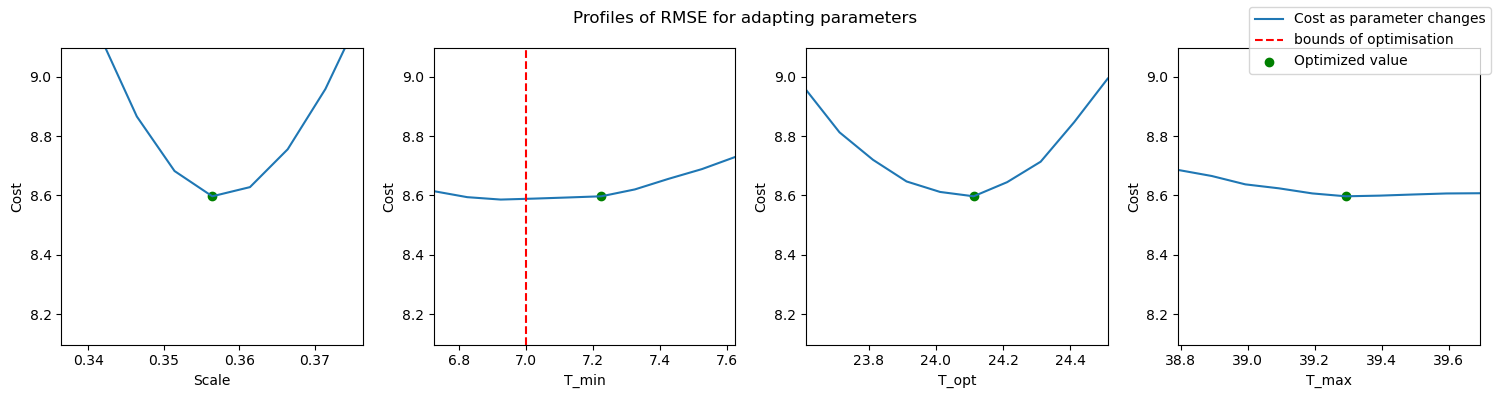

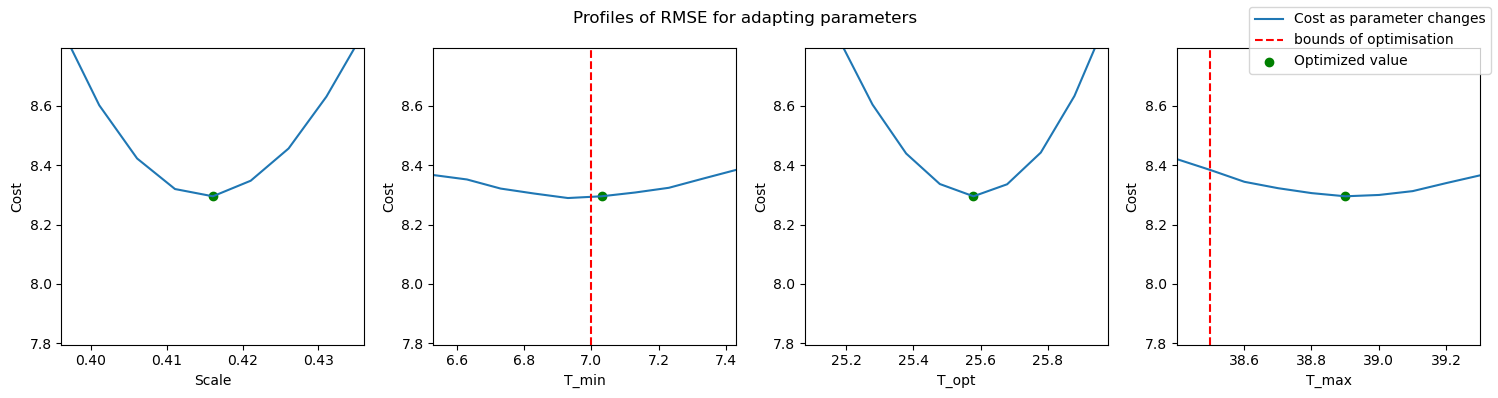

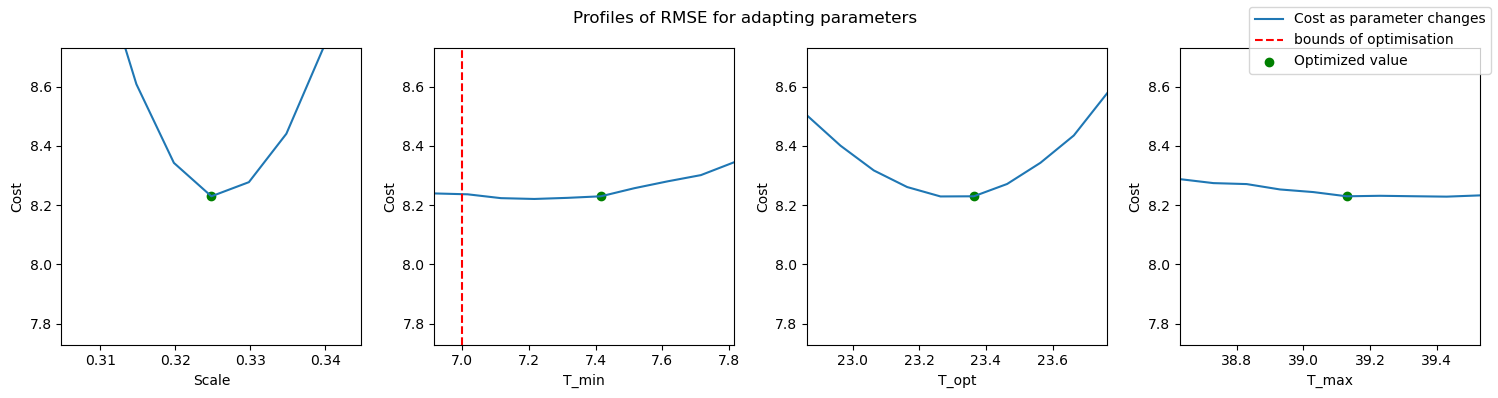

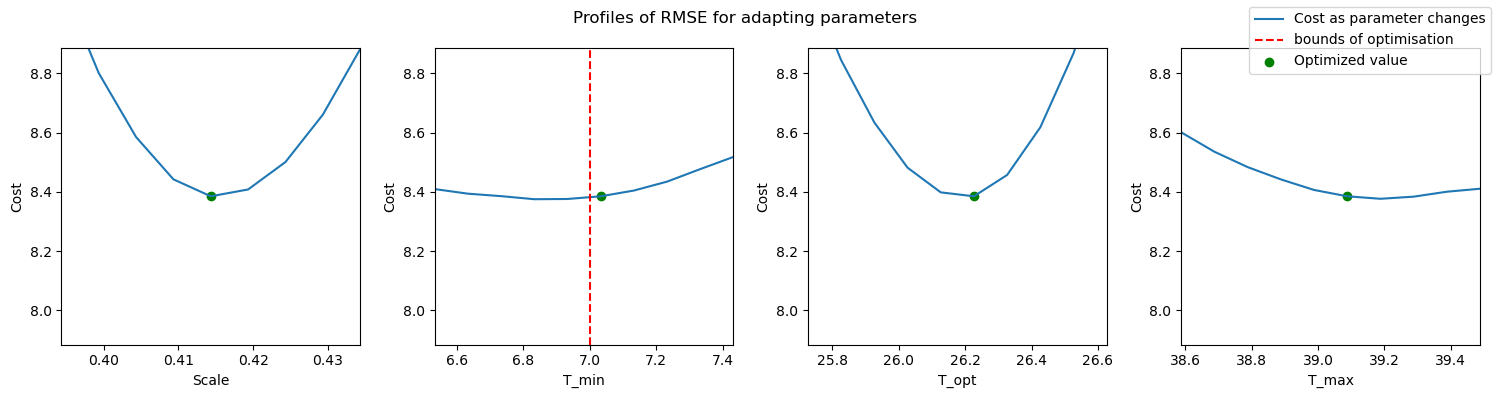

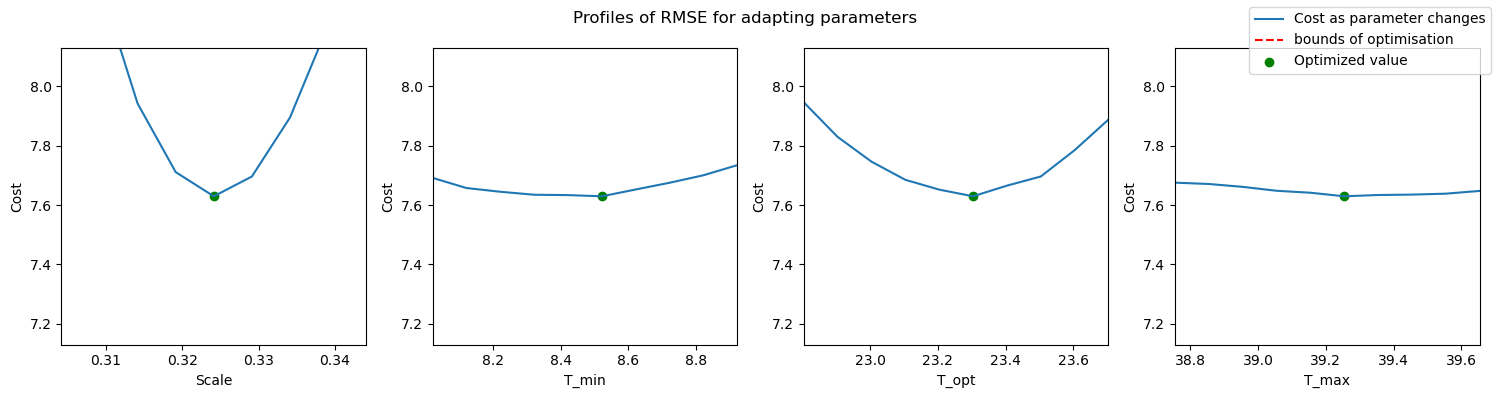

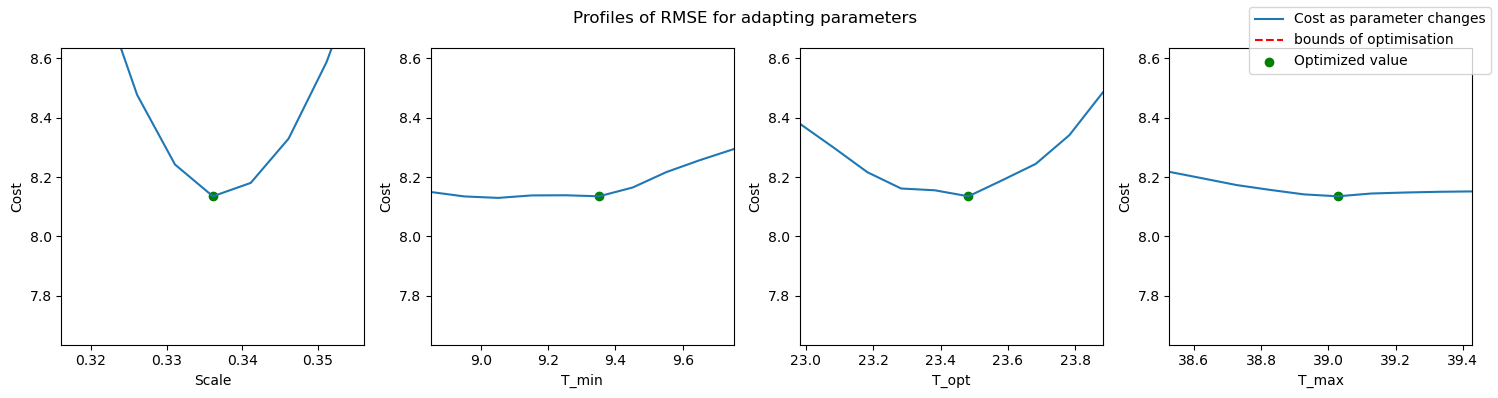

In [10]:
year_folds = [list(range(1991 + 6*n, 1991 + 6*n + 6)) for n in range(5)] + [[2021, 2022, 2023, 2024]]
R2s, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, params = KFold_crossval(ds_inputs_DE, k_folds=5, 
                                                                                           method = 'Nelder-Mead', 
                                                                                           year_split = True, 
                                                                                           year_folds = year_folds)

In [41]:
year_folds = [list(range(1991 + 6*n, 1991 + 6*n + 6)) for n in range(5)] + [[2021, 2022, 2023, 2024]]
R2s, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, params = KFold_crossval(ds_inputs_DE, k_folds=5, 
                                                                                           method = 'Nelder-Mead', 
                                                                                           year_split = True, 
                                                                                           year_folds = year_folds,
                                                                                           response_type = 'Convolved')

Fold 1
19715 7428
Fold 1
Optimization terminated successfully.
         Current function value: 8.487812
         Iterations: 67
         Function evaluations: 152
[ 0.5  8.  24.  39. ] [ 0.51994209  8.43472288 26.74567665 38.87322564] [-0.01994209 -0.43472288 -2.74567665  0.12677436]
RMSE at opt on test set:  8.803349372971748
R^2: 0.3163631053684025
Parameters:  [ 0.51994209  8.43472288 26.74567665 38.87322564]
Fold: 1
R2: 0.3163631053683974
Bias: 2.7443063657113873
Variance: 42.97798041283109
Fold 2
21911 5232
Fold 2
Optimization terminated successfully.
         Current function value: 8.165434
         Iterations: 67
         Function evaluations: 151
[ 0.5  8.  24.  39. ] [ 0.48194174  8.36907271 25.7655107  38.9586877 ] [ 0.01805826 -0.36907271 -1.7655107   0.0413123 ]
RMSE at opt on test set:  8.881254581681558
R^2: 0.37463199318564566
Parameters:  [ 0.48194174  8.36907271 25.7655107  38.9586877 ]
Fold: 2
R2: 0.37463199318563434
Bias: 2.676783350828351
Variance: 47.322993906676

In [44]:
err_df = make_error_df(R2s, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, 'GDD Wang response', 'DE', '5-fold year CV')
err_df.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\important_results\\NEW_error_df_TREx_opt.csv')

In [47]:
np.array(params).mean(axis=0)

array([ 0.47240043,  8.41864932, 25.99539194, 38.96986355])

In [45]:
err_df

,model,region,evaluation method,R2,Bias (obs minus modelled),Variance,RMSE,STD,Corr,Min,LQ,Median,UQ,Max
0,GDD Wang response,DE,5-fold year CV,0.345159,-0.665836,45.020214,8.48119,6.707666,0.635781,-52.5,-5.666667,-1.166667,3.833333,49.333333


In [21]:
err_df = make_error_df(R2s, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, 'GDD Wang response', 'DE', '5-fold year CV')
err_df.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\important_results\\NEW_error_df_GDD.csv')

In [22]:
err_df

,model,region,evaluation method,R2,Bias (obs minus modelled),Variance,RMSE,STD,Corr,Min,LQ,Median,UQ,Max
0,GDD Wang response,DE,5-fold year CV,0.287746,-0.427039,77.43525,8.65675,8.716122,0.64079,-55.666667,-5.666667,-0.666667,4.5,51.666667


### Now with just optimising the scale (TTR) parameter (still Sections 3.1 and 3.2)

In [9]:
year_folds = [list(range(1991 + 6*n, 1991 + 6*n + 6)) for n in range(5)] + [[2021, 2022, 2023, 2024]]
R2s2, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, params2 = KFold_crossval(ds_inputs_DE, k_folds=5, 
                                                                                           method = 'Nelder-Mead', 
                                                                                           year_split = True, 
                                                                                           year_folds = year_folds,
                                                                                           just_scale=True,
                                                                                           response_type = 'Convolved_vary_spread')

Fold 1
19715 7428
Fold 1
 
 Func-count     x          f(x)          Procedure
    1        1.91601      52.2745        initial
    2        3.09399      63.5499        golden
    3        1.18798      36.0203        golden
    4       0.738031      14.7823        golden
    5       0.459948      23.0546        golden
    6       0.739715      14.8958        parabolic
    7        0.64181      9.20532        parabolic
    8       0.572345       9.4273        golden
    9       0.611407      8.50506        parabolic
   10       0.609457      8.49132        parabolic
   11       0.603301      8.51144        parabolic
   12       0.607106      8.49758        golden
   13       0.608871      8.49277        parabolic
   14       0.610202      8.49657        golden
   15       0.609337      8.49231        parabolic
   16       0.609742      8.49209        golden
   17        0.60955      8.49173        parabolic
   18       0.609411      8.49185        golden
   19       0.609484      8.49244

In [19]:
year_folds = [list(range(1991 + 6*n, 1991 + 6*n + 6)) for n in range(5)] + [[2021, 2022, 2023, 2024]]
R2s2, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, params2 = KFold_crossval(ds_inputs_DE, k_folds=5, 
                                                                                           method = 'Nelder-Mead', 
                                                                                           year_split = True, 
                                                                                           year_folds = year_folds,
                                                                                           just_scale=True,
                                                                                           response_type = 'Wang')

Fold 1
19715 7428
Fold 1
 
 Func-count     x          f(x)          Procedure
    1        1.91601      40.8314        initial
    2        3.09399      51.7871        golden
    3        1.18798      26.3409        golden
    4       0.738031      10.4438        golden
    5       0.459948        28.04        golden
    6       0.832579      13.3105        parabolic
    7       0.631813       11.868        golden
    8       0.715701      10.1619        parabolic
    9       0.706525      10.1277        parabolic
   10       0.704517      10.1318        parabolic
   11       0.707493      10.1367        parabolic
   12       0.705789      10.1349        parabolic
   13       0.706895      10.1295        golden
   14       0.706244      10.1275        golden
   15       0.706338      10.1273        parabolic
   16       0.706368      10.1269        parabolic
   17       0.706428      10.1272        golden
   18       0.706386      10.1273        parabolic
   19       0.706357      10.1

In [20]:
err_df = make_error_df(R2s2, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, 'GDD Wang response', 'DE', '5-fold year CV')
err_df.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\important_results\\NEW_error_df_GDD_Sanchez.csv')

### In case it is easier, repeat the code in SSA (CIMMYT data) here so all in one place. Also in other file.

In [45]:
R2s2, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, params2 = KFold_crossval(ds_inputs_SSA, k_folds=5, 
                                                                                           method = 'Nelder-Mead', 
                                                                                           year_split = False)

Fold 1
Optimization terminated successfully.
         Current function value: 8.959518
         Iterations: 73
         Function evaluations: 172
[ 0.5  8.  28.  39. ] [ 0.30567229  7.         23.75562448 39.63485568] [ 0.19432771  1.          4.24437552 -0.63485568]
RMSE at opt on test set:  10.665271239405005
R^2: 0.3054460060798855
Parameters:  [ 0.30567229  7.         23.75562448 39.63485568]
Fold: 1
R2: 0.27612299302660903
Bias: -0.20424403183023873
Variance: 54.65400135447848
Fold 2
Optimization terminated successfully.
         Current function value: 9.297445
         Iterations: 81
         Function evaluations: 179
[ 0.5  8.  28.  39. ] [ 0.31088058  7.88814778 23.73499127 39.68957126] [ 0.18911942  0.11185222  4.26500873 -0.68957126]
RMSE at opt on test set:  9.627739290425016
R^2: 0.21729874130006366
Parameters:  [ 0.31088058  7.88814778 23.73499127 39.68957126]
Fold: 2
R2: 0.15696737484377876
Bias: 0.37299771167048057
Variance: 7.724287783679384
Fold 3
Optimization termina

In [22]:
err_df = make_error_df(R2s2, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, 'GDD Wang response', 'SSA', '5-fold CV')
err_df.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\important_results\\NEW_error_df_GDD_SSA.csv')

In [23]:
err_df

,model,region,evaluation method,R2,Bias (obs minus modelled),Variance,RMSE,STD,Corr,Min,LQ,Median,UQ,Max
0,GDD Wang response,SSA,5-fold CV,0.231083,-0.1425,74.411211,9.639302,7.006476,0.573188,-27.4,-5.2,-0.2,5.2,27.6


In [63]:
np.array(params).mean(axis=0)

array([ 0.47240043,  8.41864932, 25.99539194, 38.96986355])

In [21]:
np.array(params2).mean(axis=0)

array([ 0.31151413,  7.34498966, 24.11898113, 39.61041913])

In [19]:
np.array(params2).mean(axis=0)

array([ 0.31151413,  7.34498966, 24.11898113, 39.61041913])

In [27]:
err_df2 = make_error_df(R2s2, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, 'GDD js', 'SSA', '5-fold CV')
err_df2

,model,region,evaluation method,R2,Bias (obs minus modelled),Variance,RMSE,STD,Corr,Min,LQ,Median,UQ,Max
0,GDD js,SSA,5-fold CV,-3.085315,7.119378,566.825612,17.050363,20.627427,0.604742,-53.8,1.75,11.6,16.4,38.6


In [32]:
err_df2 = make_error_df(R2s2, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, 'GDD js', 'DE', '5-fold CV')
err_df2

,model,region,evaluation method,R2,Bias (obs minus modelled),Variance,RMSE,STD,Corr,Min,LQ,Median,UQ,Max
0,GDD js,DE,5-fold CV,0.031107,0.947959,158.801274,10.777689,12.599348,0.590109,-78.6,-5.4,1.0,7.6,49.6


In [36]:
err_df2 = make_error_df(R2s2, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, 'GDD ER', 'DE', '5-fold CV')
err_df2

,model,region,evaluation method,R2,Bias (obs minus modelled),Variance,RMSE,STD,Corr,Min,LQ,Median,UQ,Max
0,GDD ER,DE,5-fold CV,0.297687,-0.617124,59.793033,8.600677,7.728308,0.626444,-54.666667,-5.833333,-0.833333,4.166667,51.166667


In [22]:
err_df2 = make_error_df(R2s2, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, 'GDD', 'SSA', '5-fold CV')
err_df2

,model,region,evaluation method,R2,Bias (obs minus modelled),Variance,RMSE,STD,Corr,Min,LQ,Median,UQ,Max
0,GDD,SSA,5-fold CV,0.198491,-0.28842,75.340472,9.822872,6.911113,0.555102,-27.6,-5.8,0.0,5.2,27.6


In [20]:
err_df2

,model,region,evaluation method,R2,Bias (obs minus modelled),Variance,RMSE,STD,Corr,Min,LQ,Median,UQ,Max
0,accumulated NN response,DE,5-fold year CV,0.293839,-0.427039,77.43525,8.65675,8.716122,0.64079,-55.666667,-5.666667,-0.666667,4.5,51.666667


### Figure 2: distribution of flowering times in each region

Text(0.5, 1.0, 'Distribution of observed days to beginning of flowering\nin evaluation datasets')

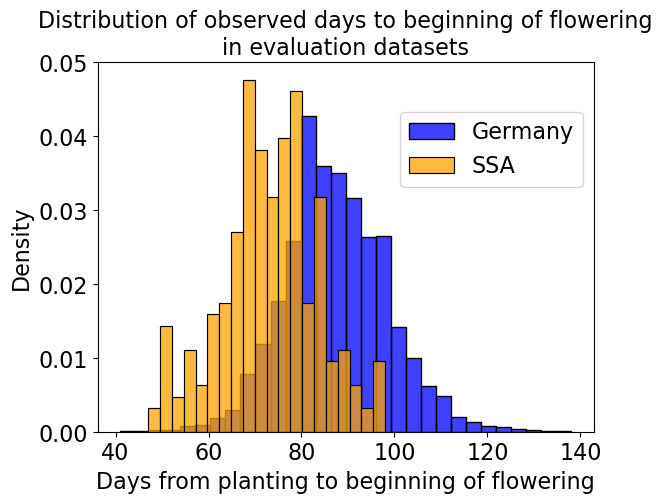

In [19]:
font_size = 16
fig, ax = plt.subplots()
sns.histplot(ds_inputs_DE['observed time to beginning of flowering'], color = 'blue', label = 'Germany', stat = 'density', ax = ax, bins=30)
sns.histplot(ds_inputs_SSA['observed time to beginning of flowering'], color = 'orange', label = 'SSA', stat = 'density', ax = ax, bins=20)
ax.set_xlabel('Days from planting to beginning of flowering', fontsize = font_size)
fig.legend(bbox_to_anchor = (0.9, 0.8), fontsize = font_size)
ax.tick_params(axis='both', which='major', labelsize=font_size)
ax.set_ylabel('Density', fontsize = font_size)
ax.set_title('Distribution of observed days to beginning of flowering\nin evaluation datasets', fontsize = font_size)

### Supplementary Figures 2 and 3 (adapt for residuals)

In [ ]:
#train_ds, test_ds = train_test_split(ds_inputs_DE)
train_a, test_a = train_test_by_year(ds_inputs_DE, [2020, 2021, 2022])
x_1 = scipy.optimize.minimize_scalar(lambda x: run_GDD_and_get_RMSE([x] + [9.3, 28.3, 39.2], train_a, 't2m', response_type='Wang', thresholds = [20], growing_period_length = 180),
                                            bounds = (0, 1),
                                            method='bounded',
                                            options = {'disp': 3})

 
 Func-count     x          f(x)          Procedure
    1       0.381966      54.9089        initial
    2       0.618034      12.2599        golden
    3       0.763932      13.0219        golden
    4       0.685617      11.0189        parabolic
    5       0.682312      11.0098        parabolic
    6       0.679777      11.0131        parabolic
    7       0.681975       11.008        parabolic
    8       0.681258      11.0106        parabolic
    9        0.68183      11.0057        parabolic
   10       0.681612      11.0057        golden
   11       0.681719      11.0045        parabolic
   12       0.681723      11.0045        parabolic
   13       0.681734      11.0043        parabolic
   14       0.681771      11.0048        golden
   15       0.681748      11.0044        golden
   16       0.681738      11.0044        parabolic
   17        0.68173      11.0044        golden

Optimization terminated successfully;
The returned value satisfies the termination criteria
(using 

39 stations out of 27143 did not reach the end of phase 'beginning of flowering'
R^2 value for model: 0.034220271323906815
Bias: 6.076135093174178 (sign 1.0)
Variance of modelled values: 152.2659958906789


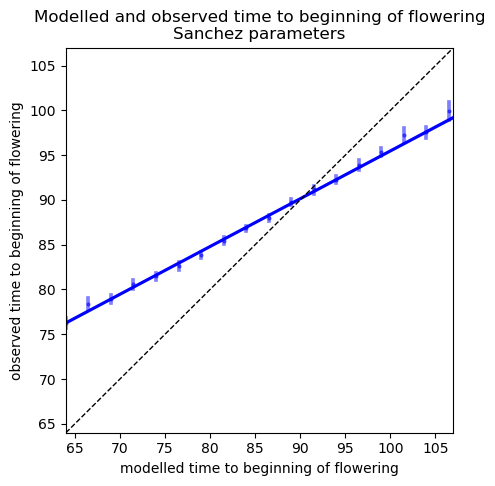

In [38]:
x_wang = 0.684018
comp_frame_wang =run_GDD([x_wang, 9.3, 28.3, 39.2], ds_inputs_DE, 't2m', response_type='Wang',#_early fm_flowering_all_DE2[0][0], x_1.x
        phase_list = ['beginning of flowering'], exclude_unfinished=False, growing_period_length=140,
        thresholds = [20], title_extra='Sanchez parameters', method = 'regression', plot=True, col='blue')

0 stations out of 27143 did not reach the end of phase 'beginning of flowering'
R^2 value for model: 0.3972246324920605
Bias: 0.025660397369070075 (sign 1.0)
Variance of modelled values: 69.2250602975806


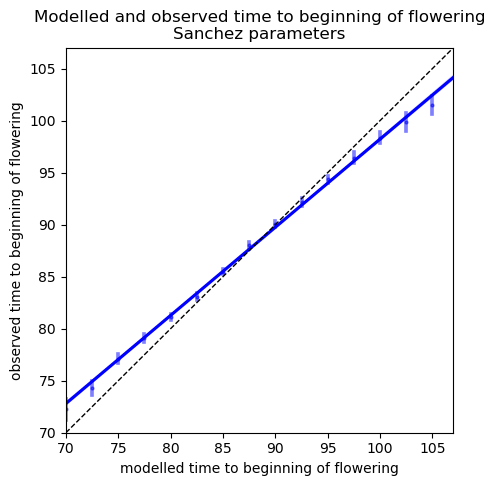

In [39]:
#x_1 = 0.684018
comp_frame_wangopt =run_GDD([x_1.x, 8.1, 22.8, 38.9], ds_inputs_DE, 't2m', response_type='Wang',#_early fm_flowering_all_DE2[0][0], x_1.x
        phase_list = ['beginning of flowering'], exclude_unfinished=False, growing_period_length=140,
        thresholds = [20], title_extra='Sanchez parameters', method = 'regression', plot=True, col='blue')

0 stations out of 27143 did not reach the end of phase 'beginning of flowering'
R^2 value for model: 0.383717157658344
Bias: 0.17537836889320027 (sign -1.0)
Variance of modelled values: 60.40683267682866


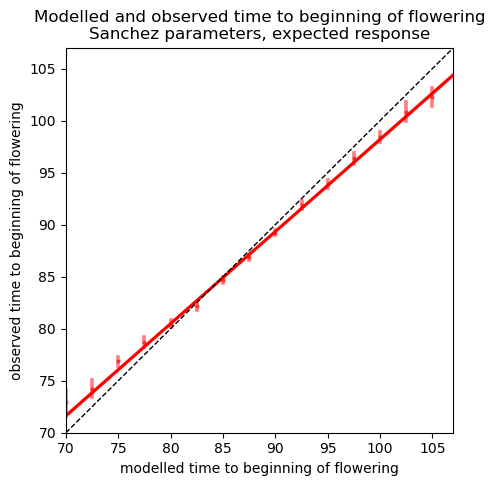

In [40]:
x_0_conv =  0.587931
comp_frame_conv =run_GDD([x_0_conv, 9.3, 28.3, 39.2, 8, 3], ds_inputs_DE, 't2m', response_type='Convolved_vary_spread',#_early fm_flowering_all_DE2[0][0], x_0_conv.x
        phase_list = ['beginning of flowering'], exclude_unfinished=False, growing_period_length=140,
        thresholds = [20], title_extra='Sanchez parameters, expected response', method = 'regression', plot=True, col='red')

0 stations out of 27143 did not reach the end of phase 'beginning of flowering'
R^2 value for model: 0.40109204928120845
Bias: 0.26025296799479425 (sign -1.0)
Variance of modelled values: 45.08697402848855


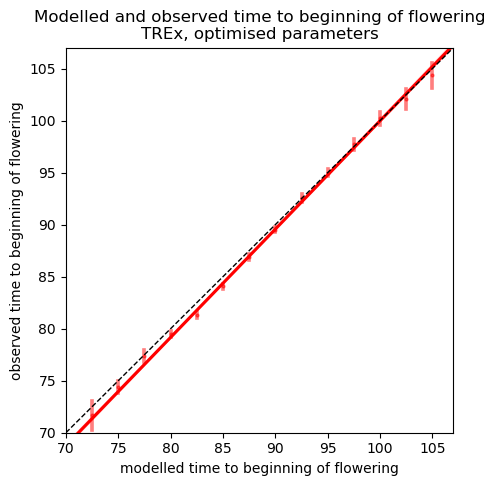

In [41]:
x_0_conv =  0.587931
comp_frame_convopt =run_GDD([ 0.47240043, 8.41864932, 25.99539194, 38.96986355, 8, 3], ds_inputs_DE, 't2m', response_type='Convolved_vary_spread',#_early fm_flowering_all_DE2[0][0], x_0_conv.x
        phase_list = ['beginning of flowering'], exclude_unfinished=False, growing_period_length=140,
        thresholds = [20], title_extra='TREx, optimised parameters', method = 'regression', plot=True, col='red')

In [26]:
comp_frames = {
    'Wang': {
        'Sanchez': comp_frame_wang,
        'Optimised': comp_frame_wangopt
    },
    'T-REx': {
        'Sanchez': comp_frame_conv,
        'Optimised': comp_frame_convopt
    }
}

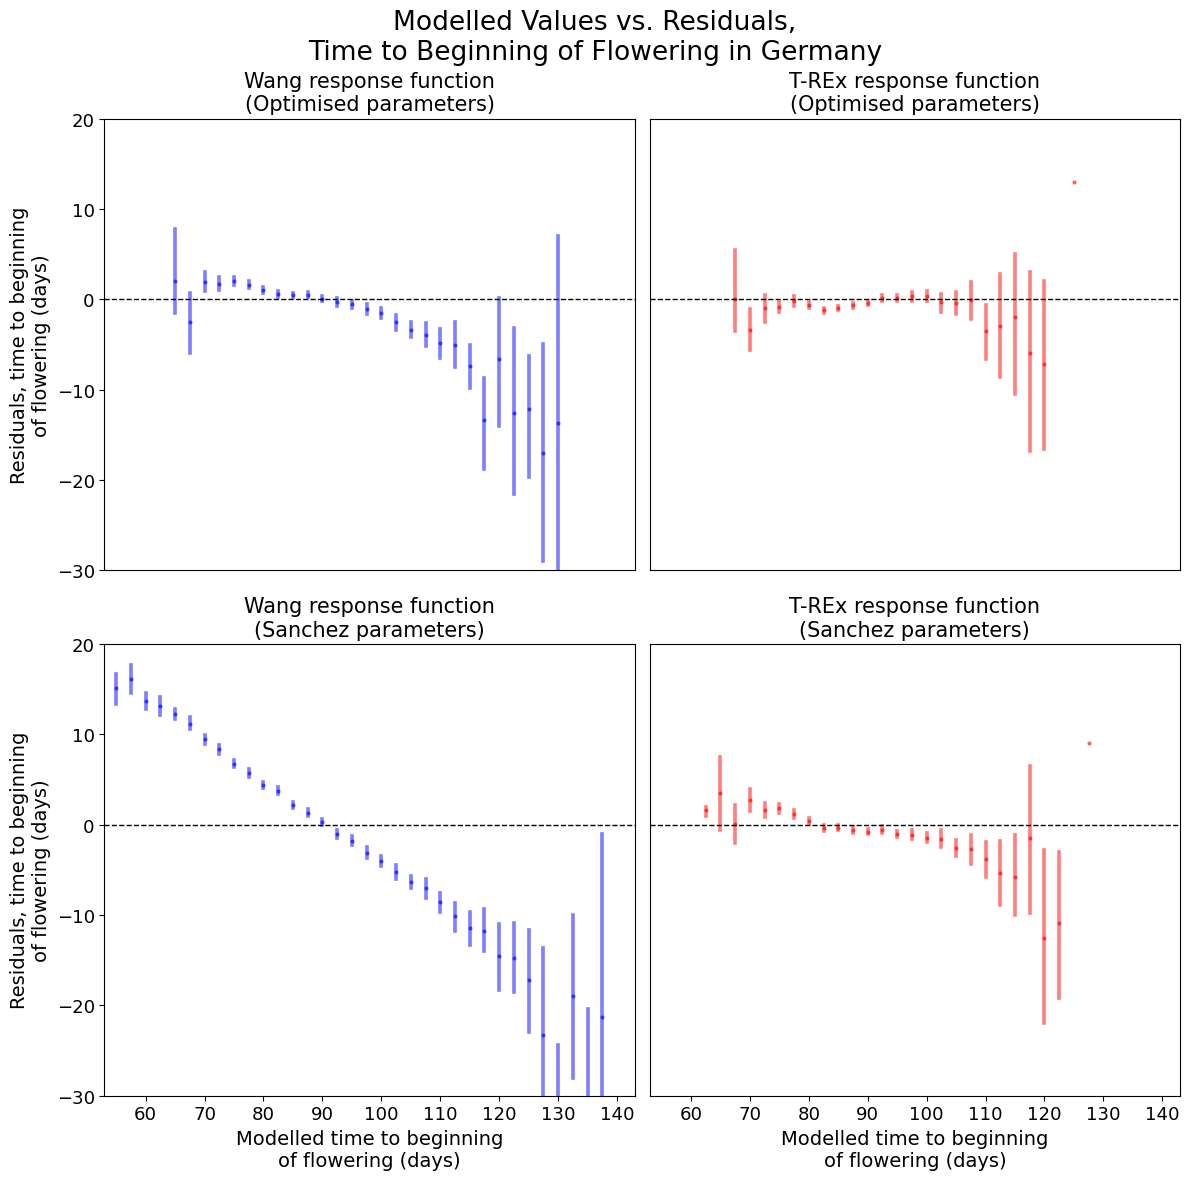

In [61]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
font_size = 20
for i in range(2):
    response = ['Wang', 'T-REx'][i]
    for j in range(2):
        param_type = ['Optimised', 'Sanchez'][j]
        ax = axs[j, i]
        minval = 53
        maxval = 143
        font_size = 14
        comp_frames[response][param_type]['Residuals'] = comp_frames[response][param_type]['observed time to beginning of flowering'] - comp_frames[response][param_type]['modelled time to beginning of flowering']
        sns.regplot(y='Residuals', x = 'modelled time to beginning of flowering', 
                    data=comp_frames[response][param_type], ax=ax, x_bins = np.arange(30, 200, 2.5),
                    scatter_kws={'alpha':0.5, 's':4}, color='blue' if response == 'Wang' else 'red',
                    fit_reg = False)
        #ax.plot([minval, maxval], [minval, maxval], linestyle='--', color='k', lw=1, scalex=False, scaley=False)
        ax.axhline(0, linestyle='--', color='k', lw=1)
        ax.set_xlim(minval, maxval)
        ax.set_ylim(-30, 20)#minval, maxval)
        ax.set_xlabel('Modelled time to beginning\nof flowering (days)', fontsize=font_size)
        ax.set_title(f'{response} response function\n({param_type} parameters)', fontsize=font_size + 1)
        ax.tick_params(labelsize=font_size - 1)
axs[0, 0].set_ylabel('Residuals, time to beginning\nof flowering (days)', fontsize=font_size)
axs[0, 0].tick_params(bottom = False, labelbottom=False, labelsize=font_size - 1)
axs[0, 0].set_xlabel('')
axs[1, 0].set_ylabel('Residuals, time to beginning\nof flowering (days)', fontsize=font_size)
axs[1, 0].set_xlabel('Modelled time to beginning\nof flowering (days)', fontsize=font_size)
axs[0, 1].tick_params(left = False, labelleft=False,
                          bottom = False, labelbottom=False)
axs[0,1].set_xlabel('')
axs[0, 1].set_ylabel('')
axs[1, 1].set_xlabel('Modelled time to beginning\nof flowering (days)', fontsize=font_size)
axs[1, 1].tick_params(left = False, labelleft=False)
axs[1, 1].set_ylabel('')
        
plt.tight_layout()

fig.suptitle('Modelled Values vs. Residuals,\nTime to Beginning of Flowering in Germany', fontsize=font_size + 5)
fig.tight_layout()
fig.savefig('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\plots\\for paper\\all_PBMs.png')